# 🏦 Prêt à Dépenser — Interprétation SHAP du Modèle de Scoring Crédit

## Objectif
Analyser et expliquer les décisions du modèle champion (Phase 3 / Phase 4) :
- **Feature Importance Globale** : quelles variables influencent le modèle en général
- **Feature Importance Locale** : pourquoi UN client précis a été refusé ou accepté
- **Score Métier** : calcul de 10×FN + 1×FP avec seuil optimal

> ⚠️ Prérequis : avoir exécuté `make phase4` (ou phase4) avec `--save-all`


## ⬇️ 1. Imports

In [4]:
import joblib
import json
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import shap

from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
    fbeta_score,
    classification_report,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics    import make_scorer

# Affichage élargi
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.expand_frame_repr', False)

print("✅ Imports OK")


✅ Imports OK


## ⚙️ 2. Configuration — Chemins & Constantes

In [5]:
# ─── Chemins (adapter si nécessaire) ──────────────────────────────────────

# Configuration des chemins
RAW_DATA_DIR     = Path("../data/raw")
INTERIM_DATA_DIR = Path("../data/interim")
PREPROCESED_DIR  = Path("../data/processed")
REPORTS_DIR      = Path("../reports")
MODELS_DIR       = Path("../models/")                # Use a folder for each Version 

REPORTS_DIR.mkdir(exist_ok=True)

# ─── Nom du modèle champion ────────────────────────────────────────────────
# Changer ici si vous voulez analyser un autre modèle (ex: "xgboost", "random_forest")
CHAMPION_NAME = "phase4_best_model"

# ─── Coûts métier ─────────────────────────────────────────────────────────
COUT_FN = 10   # Faux Négatif : mauvais client → crédit accordé → perte capital
COUT_FP = 1    # Faux Positif : bon client → crédit refusé → manque à gagner

print(f"📁 MODELS_DIR  : {MODELS_DIR.absolute()}")
print(f"🏆 Champion    : {CHAMPION_NAME}")
print(f"💰 Coût FN     : {COUT_FN}×  |  Coût FP : {COUT_FP}×")


📁 MODELS_DIR  : C:\Users\Public\IAE_DELL\pra_dell\m6_ocr\notebooks\..\models
🏆 Champion    : phase4_best_model
💰 Coût FN     : 10×  |  Coût FP : 1×


## 📦 3. Chargement du modèle et des données

In [8]:
# ── 3.1 Modèle champion ───────────────────────────────────────────────────
model_path = MODELS_DIR / f"{CHAMPION_NAME}.joblib"
model      = joblib.load(model_path)
print(f"✅ Modèle chargé : {type(model).__name__}  ({model_path})")

# ── 3.2 Métadonnées (métriques, feature names, run_id ...) ────────────────
meta_path = MODELS_DIR / f"{CHAMPION_NAME}_metadata.json"
with open(meta_path, encoding="utf-8") as f:
    metadata = json.load(f)

feature_names   = metadata["feature_names"]
mlflow_run_id   = metadata.get("mlflow_run_id", "N/A")
eval_metrics    = metadata["phase4_eval_metrics"]

print(f"✅ Métadonnées   : {len(feature_names)} features  |  run_id={mlflow_run_id[:8]}...")
print(f"   AUC-ROC eval  : {eval_metrics.get('roc_auc', 'N/A')}")
print(f"   F2 eval       : {eval_metrics.get('f2', 'N/A')}")

# ── 3.3 Datasets train / eval ─────────────────────────────────────────────
# Produit par step6_save() dans phase3 → models/split_data_score.joblib
split_path  = MODELS_DIR / "split_data_score.joblib"
data_bundle = joblib.load(split_path)

X_train = data_bundle["X_train"]
X_test  = data_bundle["X_test"]   # = X_eval (holdout phase3)
y_train = data_bundle["y_train"]
y_test  = data_bundle["y_test"]

# Réaligner les colonnes sur celles connues du modèle (garde-fou)
X_train = X_train.reindex(columns=feature_names, fill_value=0)
X_test  = X_test.reindex(columns=feature_names,  fill_value=0)

print(f"✅ Données       : X_train={X_train.shape}  X_test={X_test.shape}")
print(f"   Taux défaut   : train={y_train.mean():.1%}  eval={y_test.mean():.1%}")


✅ Modèle chargé : DecisionTreeClassifier  (..\models\phase4_best_model.joblib)
✅ Métadonnées   : 232 features  |  run_id=N/A...
   AUC-ROC eval  : 0.7116
   F2 eval       : 0.3854
✅ Données       : X_train=(246008, 232)  X_test=(61503, 232)
   Taux défaut   : train=8.1%  eval=8.1%


## 🎯 4. Probabilités de défaut & Seuil Optimal Métier

  Seuil optimal  : 0.508   (défaut = 0.5)
  Score Métier   : 33619   (10×1823 + 1×15389)
  FN (défauts non détectés)  : 1823
  FP (refus abusifs)         : 15389


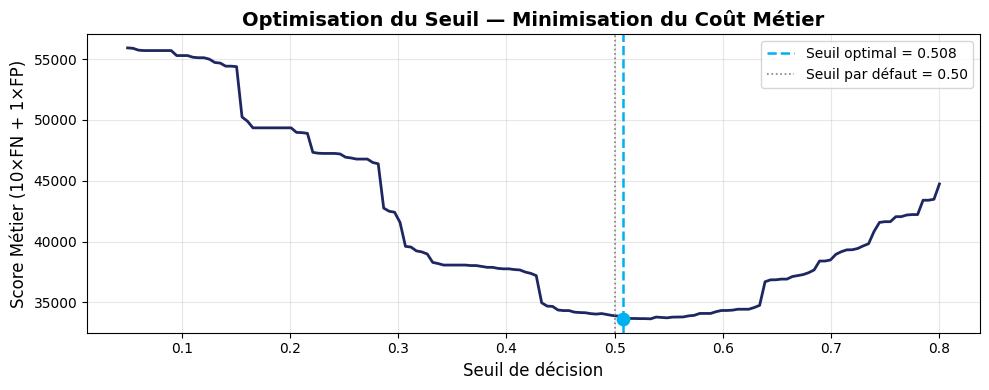

✅ Courbe sauvegardée → ..\reports/threshold_curve.png


In [9]:
# Probabilités de la classe 1 (défaut) sur le set d'évaluation
y_proba = model.predict_proba(X_test)[:, 1]

# ── Fonction Score Métier ─────────────────────────────────────────────────
def score_metier(y_true, y_proba, seuil, cout_fn=COUT_FN, cout_fp=COUT_FP):
    """Calcule 10×FN + 1×FP pour un seuil donné."""
    y_pred         = (y_proba >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return int(cout_fn * fn + cout_fp * fp), int(fn), int(fp)

# ── Balayage des seuils ────────────────────────────────────────────────────
seuils  = np.linspace(0.05, 0.80, 150)
scores  = [score_metier(y_test, y_proba, s)[0] for s in seuils]

idx_opt       = int(np.argmin(scores))
seuil_optimal = float(seuils[idx_opt])
score_opt, fn_opt, fp_opt = score_metier(y_test, y_proba, seuil_optimal)

print("=" * 55)
print(f"  Seuil optimal  : {seuil_optimal:.3f}   (défaut = 0.5)")
print(f"  Score Métier   : {score_opt}   ({COUT_FN}×{fn_opt} + {COUT_FP}×{fp_opt})")
print(f"  FN (défauts non détectés)  : {fn_opt}")
print(f"  FP (refus abusifs)         : {fp_opt}")
print("=" * 55)

# ── Courbe Score Métier vs Seuil ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(seuils, scores, color="#1E2761", linewidth=2)
ax.axvline(seuil_optimal, color="#00B0F0", linestyle="--", linewidth=1.8,
           label=f"Seuil optimal = {seuil_optimal:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Seuil par défaut = 0.50")
ax.scatter([seuil_optimal], [score_opt], color="#00B0F0", s=80, zorder=5)
ax.set_xlabel("Seuil de décision", fontsize=12)
ax.set_ylabel(f"Score Métier ({COUT_FN}×FN + {COUT_FP}×FP)", fontsize=12)
ax.set_title("Optimisation du Seuil — Minimisation du Coût Métier", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "threshold_curve.png", dpi=150)
plt.show()
print(f"✅ Courbe sauvegardée → {REPORTS_DIR}/threshold_curve.png")


## 📊 5. Performances avec le Seuil Optimal

  Métrique                         Seuil 0.50   Seuil Optimal
-----------------------------------------------------------------
  FN (défauts non détectés)              1716            1823  ⚠️
  FP (refus abusifs)                    16733           15389  ✅
  Score Métier (10×FN+FP)               33893           33619  ✅
  F2-Score                             0.4077          0.4092  ⚠️


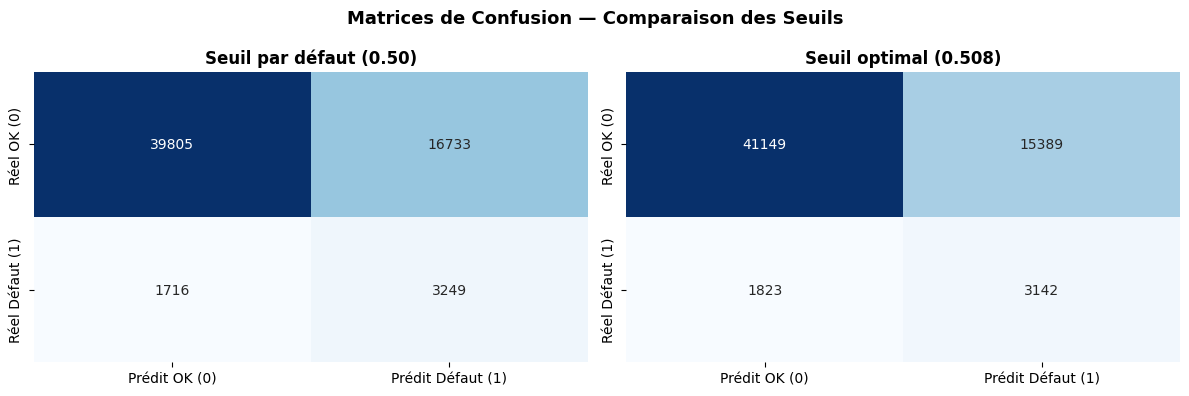

In [10]:
y_pred_opt = (y_proba >= seuil_optimal).astype(int)
y_pred_05  = (y_proba >= 0.5).astype(int)

print("=" * 65)
print(f"  {'Métrique':<30} {'Seuil 0.50':>12}  {'Seuil Optimal':>14}")
print("-" * 65)

for label, yp in [("Seuil 0.50", y_pred_05), ("Seuil optimal", y_pred_opt)]:
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    sm = COUT_FN*fn + COUT_FP*fp
    f2 = fbeta_score(y_test, yp, beta=2)

s1_tn,s1_fp,s1_fn,s1_tp = confusion_matrix(y_test, y_pred_05).ravel()
s2_tn,s2_fp,s2_fn,s2_tp = confusion_matrix(y_test, y_pred_opt).ravel()

rows = [
    ("FN (défauts non détectés)", s1_fn, s2_fn),
    ("FP (refus abusifs)",         s1_fp, s2_fp),
    ("Score Métier (10×FN+FP)",   COUT_FN*s1_fn+s1_fp, COUT_FN*s2_fn+s2_fp),
    ("F2-Score",                  round(fbeta_score(y_test,y_pred_05,beta=2),4),
                                  round(fbeta_score(y_test,y_pred_opt,beta=2),4)),
]
for label, v1, v2 in rows:
    gain = "✅" if v2 < v1 else ("➡️" if v2 == v1 else "⚠️")
    print(f"  {label:<30} {str(v1):>12}  {str(v2):>14}  {gain}")
print("=" * 65)

# ── Matrice de confusion ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (yp, title) in zip(axes, [
    (y_pred_05,  "Seuil par défaut (0.50)"),
    (y_pred_opt, f"Seuil optimal ({seuil_optimal:.3f})")
]):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Prédit OK (0)", "Prédit Défaut (1)"],
                yticklabels=["Réel OK (0)", "Réel Défaut (1)"], ax=ax)
    ax.set_title(title, fontweight="bold")
plt.suptitle("Matrices de Confusion — Comparaison des Seuils", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrices.png", dpi=150)
plt.show()


## 📈 6. Courbes ROC et Précision-Rappel

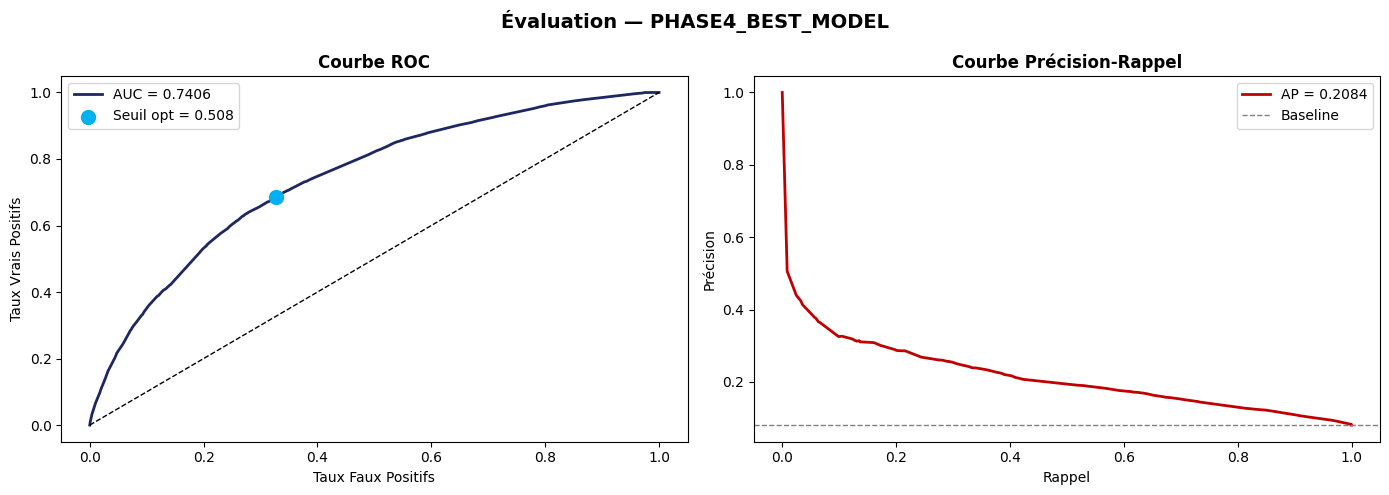

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color="#1E2761", lw=2, label=f"AUC = {roc_auc_val:.4f}")
axes[0].plot([0,1],[0,1], "k--", lw=1)

# Point au seuil optimal
idx_roc = np.argmin(np.abs(np.linspace(0, 1, len(tpr)) - seuil_optimal))
axes[0].scatter([fpr[idx_roc]], [tpr[idx_roc]], color="#00B0F0", s=100, zorder=5,
                label=f"Seuil opt = {seuil_optimal:.3f}")
axes[0].set_xlabel("Taux Faux Positifs"); axes[0].set_ylabel("Taux Vrais Positifs")
axes[0].set_title("Courbe ROC", fontweight="bold"); axes[0].legend()

# Précision-Rappel
precision, rappel, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1].plot(rappel, precision, color="#C00000", lw=2, label=f"AP = {ap:.4f}")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", lw=1, label="Baseline")
axes[1].set_xlabel("Rappel"); axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe Précision-Rappel", fontweight="bold"); axes[1].legend()

plt.suptitle(f"Évaluation — {CHAMPION_NAME.upper()}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "roc_pr_curves.png", dpi=150)
plt.show()


## 🌍 7. Feature Importance Globale

Deux approches complémentaires :
- **Native** (`feature_importances_`) : rapide, basée sur le gain d'information pendant l'entraînement
- **Permutation** : mesure l'impact réel sur le score en perturbant chaque variable sur le set d'évaluation


In [12]:
def get_feature_importance(model, X, y, top_n=20, method="auto"):
    """
    Extrait l'importance des variables.
    method: 'auto' | 'native' | 'permutation'
    """
    importances = None
    type_imp    = ""

    if method in ("auto", "native"):
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
            type_imp    = "Native (Gain/Gini)"
        elif hasattr(model, "coef_"):
            importances = np.abs(model.coef_[0])
            type_imp    = "Coefficients (valeur absolue)"

    if importances is None or method == "permutation":
        print(f"🔄 Calcul Permutation Importance (F2) pour {type(model).__name__}...")
        f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)
        r         = permutation_importance(model, X, y, n_repeats=5,
                                           scoring=f2_scorer, random_state=42, n_jobs=-1)
        importances = r.importances_mean
        type_imp    = "Permutation (F2)"

    df_imp = (
        pd.DataFrame({"Feature": X.columns, "Importance": importances})
        .sort_values("Importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    df_imp["Rang"] = range(1, len(df_imp) + 1)
    return df_imp, type_imp



🏆 TOP 20 VARIABLES — Native (Gain/Gini)
-------------------------------------------------------
   1. standard__ext_source_2                   ██████████████████████████████  0.3735
   2. standard__ext_source_3                   ████████████████████████████  0.3552
   3. standard__ext_source_1                   ██████  0.0795
   4. standard__install_payment_ratio_mean     ██  0.0330
   5. standard__days_birth                     ██  0.0267
   6. log__cc_amt_drawings_current_mean          0.0115
   7. robust__install_payment_delay_mean         0.0108
   8. standard__pos_months_balance_mean          0.0081
   9. log__amt_goods_price                       0.0077
  10. ohe__name_education_type_higher_education   0.0075
  11. ohe__code_gender_f                         0.0067
  12. log__bureau_amt_credit_sum_total           0.0052
  13. robust__install_dpd_max                    0.0046
  14. log__amt_credit                            0.0045
  15. log__amt_annuity                           0

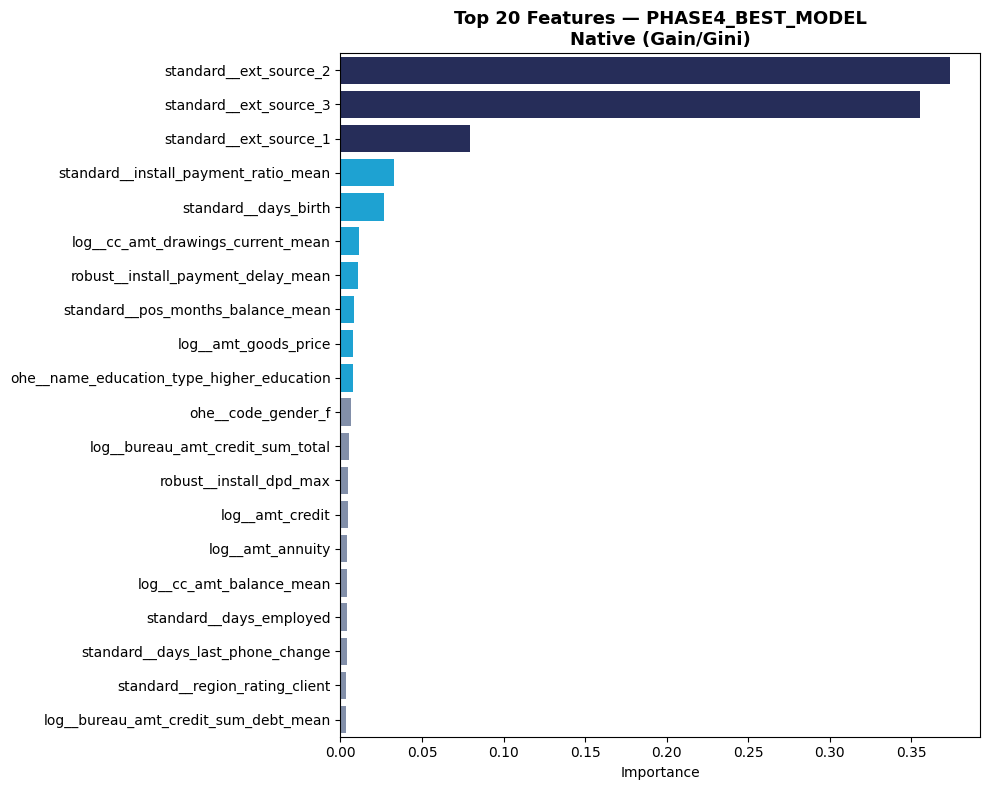

In [13]:
# ── Feature Importance native ──────────────────────────────────────────────
df_imp_native, type_native = get_feature_importance(model, X_test, y_test,
                                                    top_n=20, method="native")

print(f"\n🏆 TOP 20 VARIABLES — {type_native}")
print("-" * 55)
for _, row in df_imp_native.iterrows():
    bar = "█" * int(row["Importance"] / df_imp_native["Importance"].max() * 30)
    print(f"  {int(row['Rang']):>2}. {row['Feature']:<40} {bar}  {row['Importance']:.4f}")

# ── Graphique ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#1E2761"] * 3 + ["#00B0F0"] * 7 + ["#7B8DB0"] * 10

# Corrección del Warning: asignamos 'Feature' a 'hue' y desactivamos la leyenda
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=df_imp_native,
    hue="Feature",           # Asignamos la variable y al color (hue)
    palette=colors[:len(df_imp_native)], 
    legend=False,            # Quitamos la leyenda porque es redundante con el eje Y
    ax=ax
)

ax.set_title(f"Top 20 Features — {CHAMPION_NAME.upper()}\n{type_native}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "feature_importance_global.png", dpi=150)
plt.show()


## 🔬 8. SHAP — Configuration de l'Explainer

SHAP (SHapley Additive exPlanations) mesure la **contribution de chaque variable**
à une prédiction individuelle, en se basant sur la théorie des jeux coopératifs.


In [16]:
def get_shap_explainer(model, X_background):
    """
    Sélectionne automatiquement le bon explainer SHAP selon le type de modèle.
    - TreeExplainer  : pour LightGBM, XGBoost, RandomForest, DecisionTree
    - LinearExplainer: pour LogisticRegression
    - KernelExplainer: fallback universel (lent)
    """
    model_class = type(model).__name__

    # Pipeline imblearn (ex: SMOTE + MLP) → extraire l'estimateur final
    if hasattr(model, "steps"):
        inner = model.steps[-1][1]
        print(f"🔗 Pipeline détecté → estimateur interne : {type(inner).__name__}")
        return get_shap_explainer(inner, X_background)

    if hasattr(model, "feature_importances_"):
        print(f"🌲 TreeExplainer → {model_class}")
        return shap.TreeExplainer(model)

    elif hasattr(model, "coef_"):
        print(f"📈 LinearExplainer → {model_class}")
        return shap.LinearExplainer(model, X_background)

    else:
        print(f"🔮 KernelExplainer → {model_class}  (⚠️ peut être lent)")
        bg = shap.sample(X_background, 100)
        return shap.KernelExplainer(model.predict_proba, bg)

# ── Création de l'explainer ────────────────────────────────────────────────
explainer = get_shap_explainer(model, X_train)
print("✅ Explainer SHAP prêt")


🌲 TreeExplainer → DecisionTreeClassifier
✅ Explainer SHAP prêt


In [18]:
# ── Calcul des SHAP values ─────────────────────────────────────────────────
# On calcule sur X_test (set d'évaluation) pour une estimation non biaisée
print("⏳ Calcul des SHAP values sur X_test...")
shap_values = explainer(X_test)
print(f"✅ SHAP values calculées : shape={shap_values.values.shape}")
#print(f"   Expected value (baseline) : {explainer.expected_value:.4f}")
print(f"    Expected value (baseline) : {explainer.expected_value[1]:.4f}")


⏳ Calcul des SHAP values sur X_test...
✅ SHAP values calculées : shape=(61503, 232, 2)
    Expected value (baseline) : 0.5000


In [19]:
# DEBUG
print("⏳ Calcul des SHAP values sur X_test...")
shap_values = explainer(X_test)

print(f"✅ SHAP values calculées : shape={shap_values.values.shape}")

# Manejo robusto del expected_value
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    # Si es clasificación binaria, tomamos la clase 1
    print(f"    Expected value (clase 1) : {base_value[1]:.4f}")
else:
    print(f"    Expected value : {base_value:.4f}")

⏳ Calcul des SHAP values sur X_test...
✅ SHAP values calculées : shape=(61503, 232, 2)
    Expected value (clase 1) : 0.5000


## 🐝 9. Beeswarm Plot — Importance Globale & Distribution

Ce graphique montre **pour chaque variable** :
- L'importance (axe horizontal = amplitude de l'impact SHAP)
- Le sens : rouge = valeur élevée de la feature, bleu = valeur basse


📊 Beeswarm Plot — Top 20 variables (impact sur la probabilité de défaut)


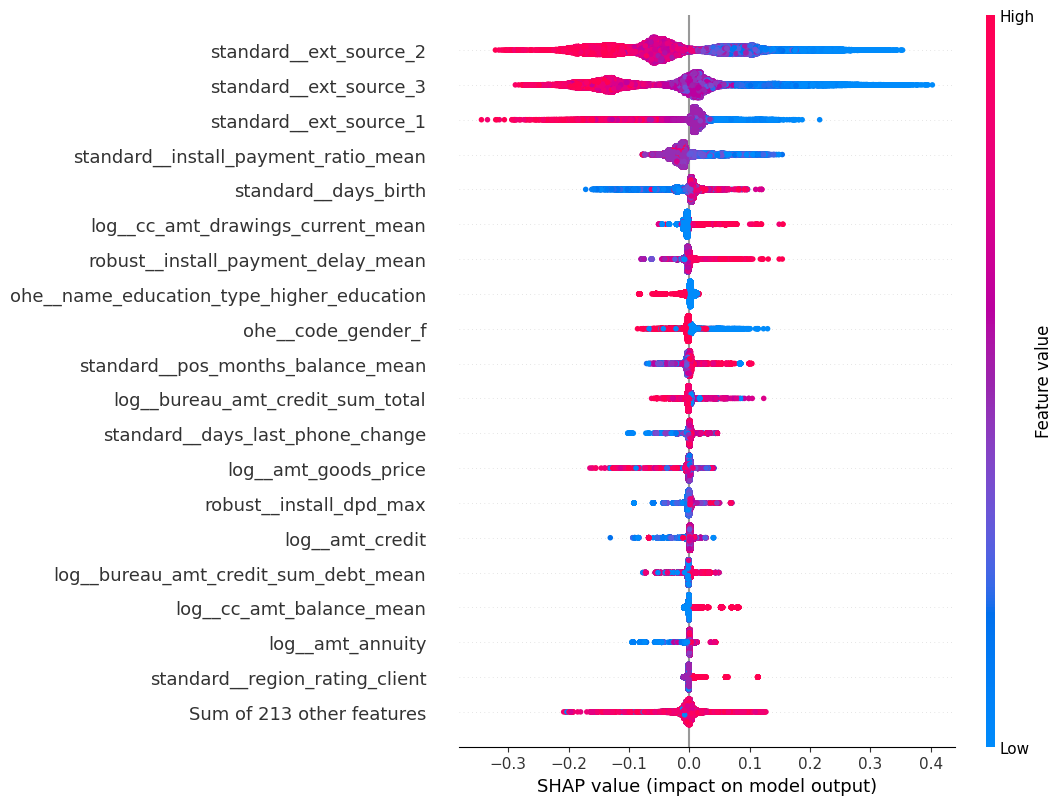

In [21]:
print("📊 Beeswarm Plot — Top 20 variables (impact sur la probabilité de défaut)")
# shap.plots.beeswarm(shap_values, max_display=20)

# Seleccionamos todas las filas, todas las columnas, pero solo la dimensión de la clase 1
# La forma pasará de (61503, 232, 2) a (61503, 232)
shap_values_clase_1 = shap_values[:, :, 1]

# Ahora ya puedes generar el gráfico
shap.plots.beeswarm(shap_values_clase_1, max_display=20)


In [23]:
# ── Top 10 SHAP (tableau) ──────────────────────────────────────────────────
# IMPORTANTE: Seleccionamos la clase 1 [:, :, 1] para medir el impacto en el riesgo
shap_importance = np.abs(shap_values.values[:, :, 1]).mean(0)


df_shap = (
    pd.DataFrame({"Feature": X_test.columns, "SHAP_mean_abs": shap_importance})
    .sort_values("SHAP_mean_abs", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("\n🏆 TOP 10 — SHAP IMPORTANCE GLOBALE MOYENNE")
print("-" * 55)
for _, row in df_shap.iterrows():
    bar = "█" * int(row["SHAP_mean_abs"] / df_shap["SHAP_mean_abs"].max() * 30)
    print(f"  {row['Feature']:<40} {bar}  {row['SHAP_mean_abs']:.4f}")

df_shap.to_csv(REPORTS_DIR / "shap_importance_globale.csv", index=False)
print(f"\n✅ Sauvegardé → {REPORTS_DIR}/shap_importance_globale.csv")



🏆 TOP 10 — SHAP IMPORTANCE GLOBALE MOYENNE
-------------------------------------------------------
  standard__ext_source_2                   ██████████████████████████████  0.0949
  standard__ext_source_3                   ███████████████████████████  0.0883
  standard__ext_source_1                   ███████████  0.0350
  standard__install_payment_ratio_mean     ███████  0.0235
  standard__days_birth                     ████  0.0139
  log__cc_amt_drawings_current_mean        ██  0.0070
  robust__install_payment_delay_mean       █  0.0053
  ohe__name_education_type_higher_education █  0.0050
  ohe__code_gender_f                       █  0.0044
  standard__pos_months_balance_mean        █  0.0042

✅ Sauvegardé → ..\reports/shap_importance_globale.csv


## 👤 10. Feature Importance Locale — Waterfall Plot (Client individuel)

Le Waterfall Plot montre **pourquoi CE client** a reçu ce score :
- Chaque barre = contribution d'une variable à sa probabilité de défaut
- Rouge = pousse vers le défaut (↑ risque)
- Bleu = protège contre le défaut (↓ risque)


📋 Analyse — BON CLIENT (TARGET=0)

  Client position #0  |  ID=256414
  Probabilité de défaut : 0.4282
  Décision (seuil 0.508) : ACCORDÉ ✅
  Réalité               : Bon payeur (0) ✅


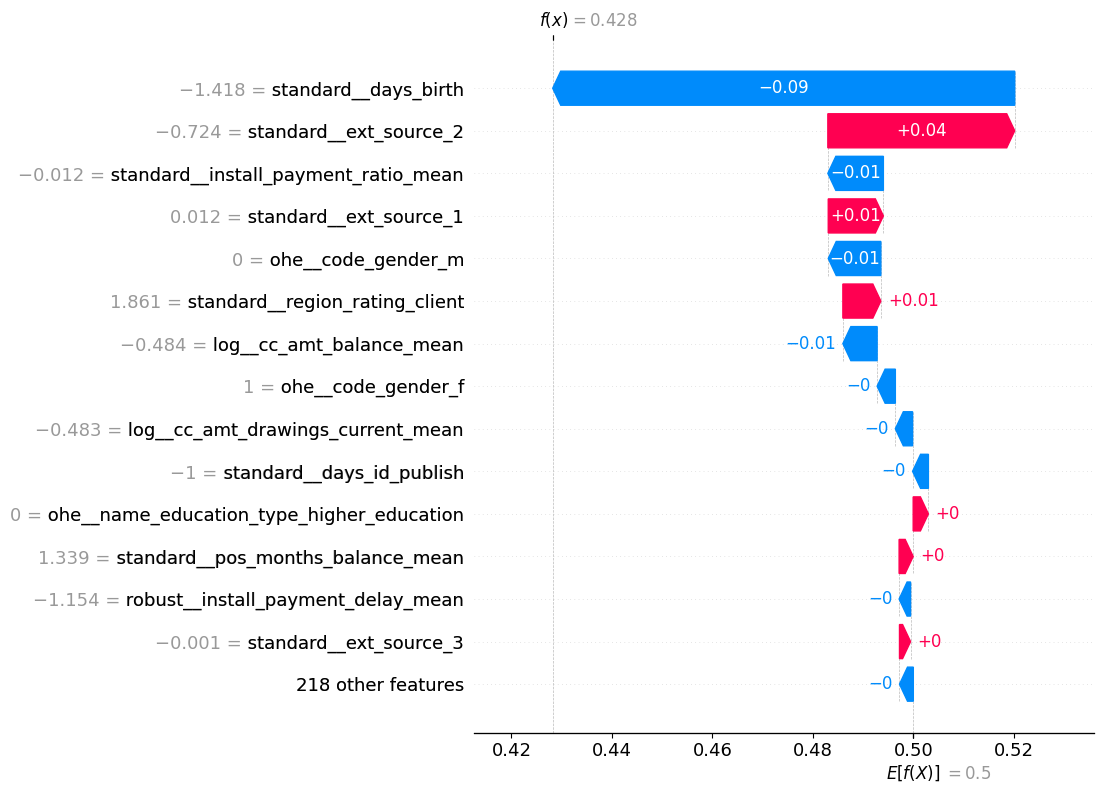


📋 Analyse — CLIENT EN DÉFAUT (TARGET=1)

  Client position #9  |  ID=256325
  Probabilité de défaut : 0.4325
  Décision (seuil 0.508) : ACCORDÉ ✅
  Réalité               : Défaut (1) ⚠️


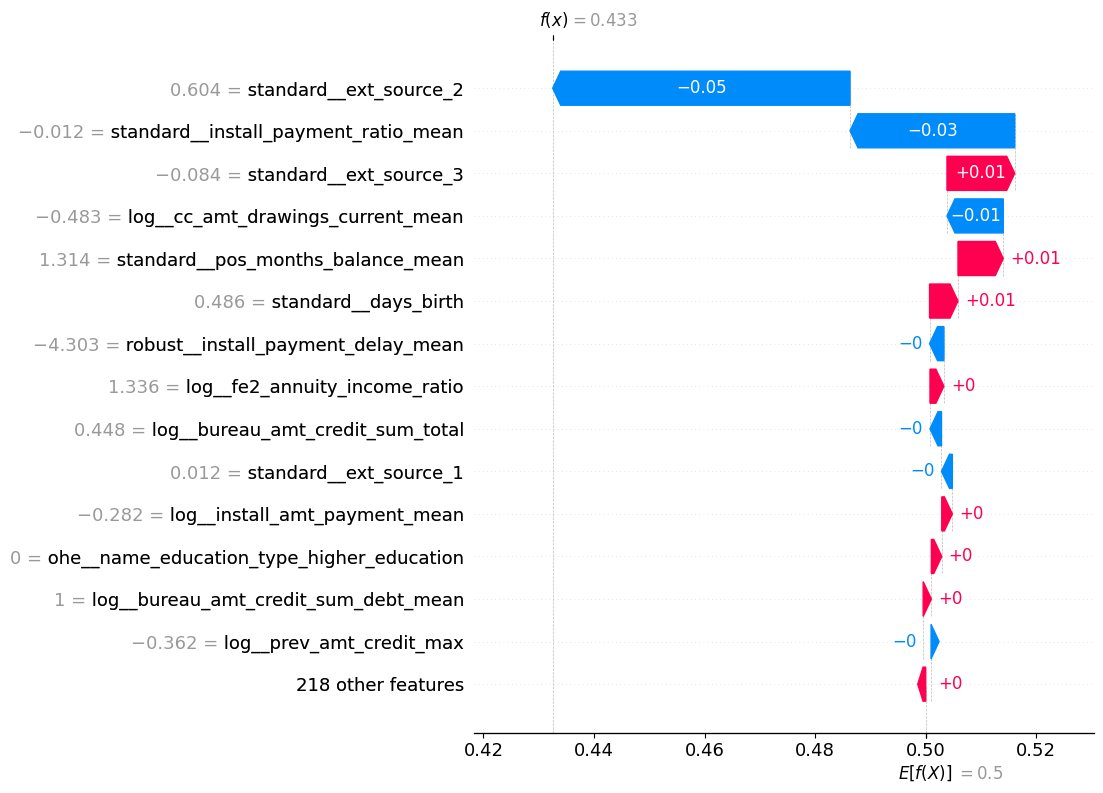

In [25]:
def analyser_client(idx_position, label="client"):
    """
    Affiche le Waterfall plot SHAP pour un client donné (par position dans X_test).
    """
    proba    = y_proba[idx_position]
    reel     = int(y_test.iloc[idx_position])
    decision = "REFUSÉ ❌" if proba >= seuil_optimal else "ACCORDÉ ✅"

    print(f"\n{'='*60}")
    print(f"  Client position #{idx_position}  |  ID={X_test.index[idx_position]}")
    print(f"  Probabilité de défaut : {proba:.4f}")
    print(f"  Décision (seuil {seuil_optimal:.3f}) : {decision}")
    print(f"  Réalité               : {'Défaut (1) ⚠️' if reel==1 else 'Bon payeur (0) ✅'}")
    print(f"{'='*60}")

    # CORRECTION : On indexe par [idx_position, :, 1] pour obtenir 
    # les explications de la CLASSE 1 (risque de défaut)
    shap_values_client = shap_values[idx_position, :, 1]
    
    shap.plots.waterfall(shap_values_client, max_display=15)

# ── Exemples : 1 bon client, 1 client à risque ────────────────────────────
idx_bon_client   = int(np.where(y_test.values == 0)[0][0])   # Premier bon client
idx_mauvais      = int(np.where(y_test.values == 1)[0][0])   # Premier client en défaut

print("📋 Analyse — BON CLIENT (TARGET=0)")
analyser_client(idx_bon_client, "bon client")

print("\n📋 Analyse — CLIENT EN DÉFAUT (TARGET=1)")
analyser_client(idx_mauvais, "client en défaut")


🔍 TOP 5 CLIENTS LES PLUS À RISQUE

  Rang 1 — Position #23189

  Client position #23189  |  ID=35571
  Probabilité de défaut : 0.9375
  Décision (seuil 0.508) : REFUSÉ ❌
  Réalité               : Défaut (1) ⚠️


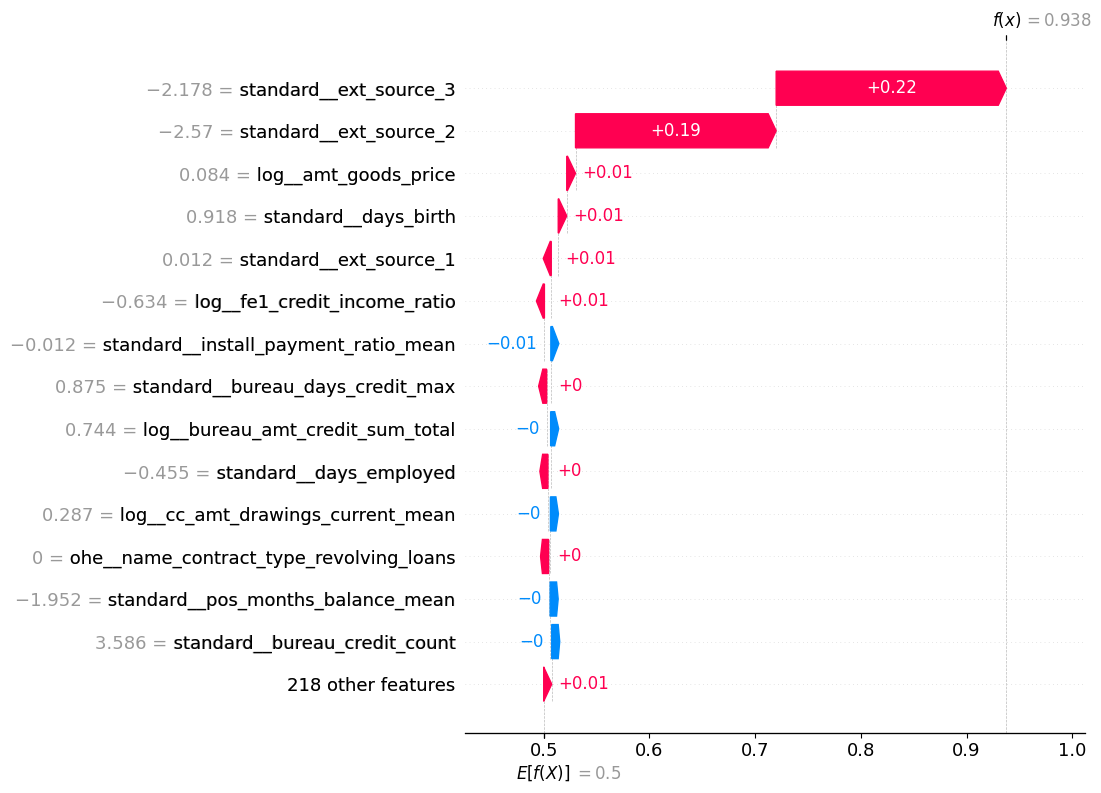


  Rang 2 — Position #39620

  Client position #39620  |  ID=244160
  Probabilité de défaut : 0.9375
  Décision (seuil 0.508) : REFUSÉ ❌
  Réalité               : Défaut (1) ⚠️


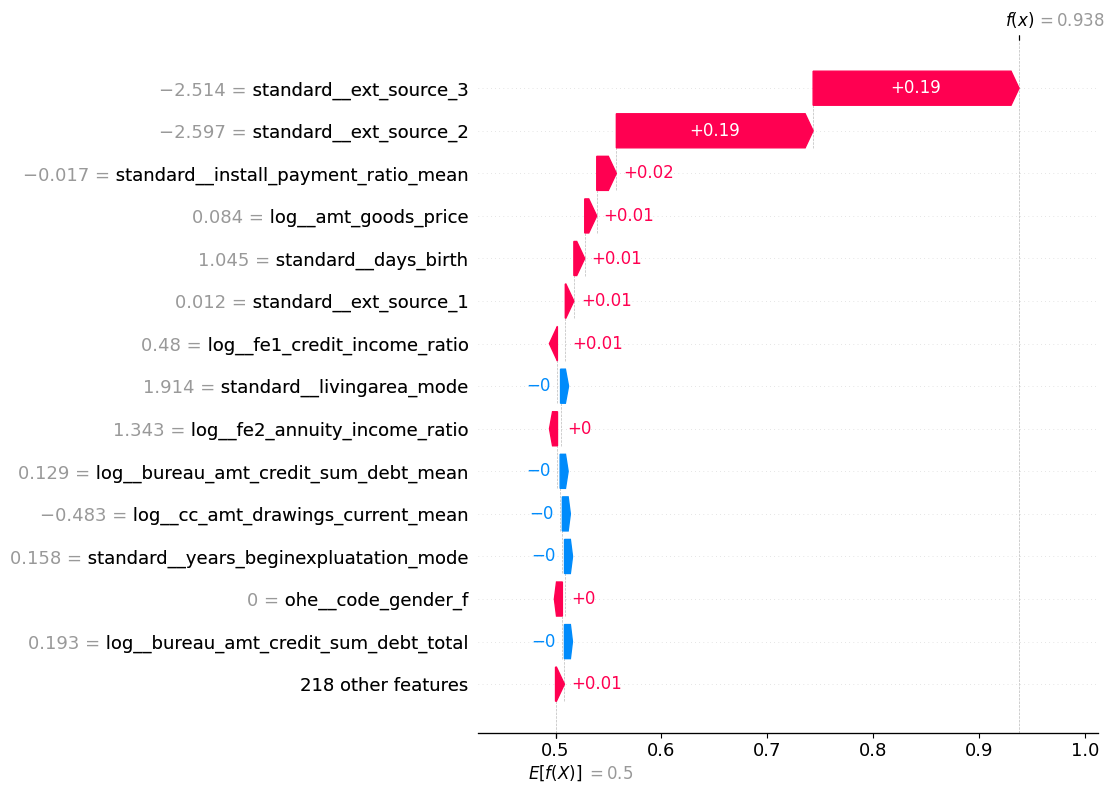


  Rang 3 — Position #29993

  Client position #29993  |  ID=58292
  Probabilité de défaut : 0.9375
  Décision (seuil 0.508) : REFUSÉ ❌
  Réalité               : Bon payeur (0) ✅


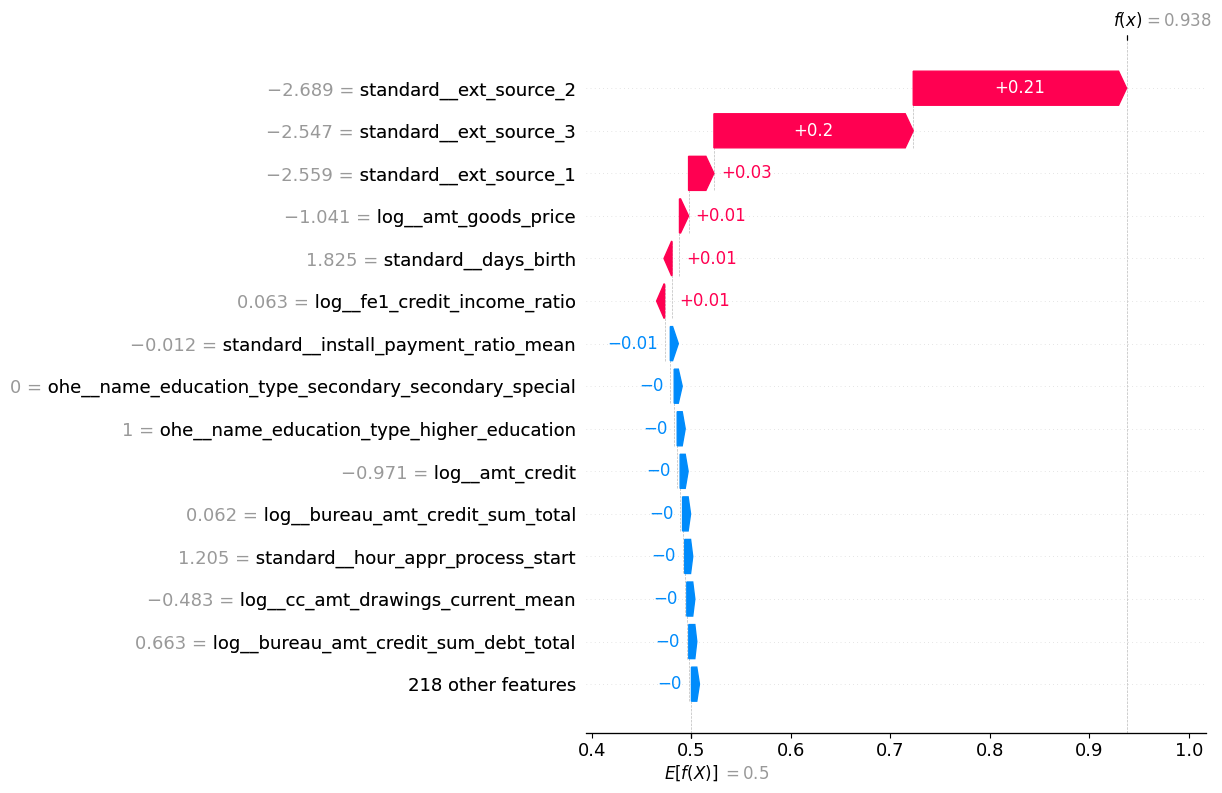


  Rang 4 — Position #15760

  Client position #15760  |  ID=297571
  Probabilité de défaut : 0.9375
  Décision (seuil 0.508) : REFUSÉ ❌
  Réalité               : Bon payeur (0) ✅


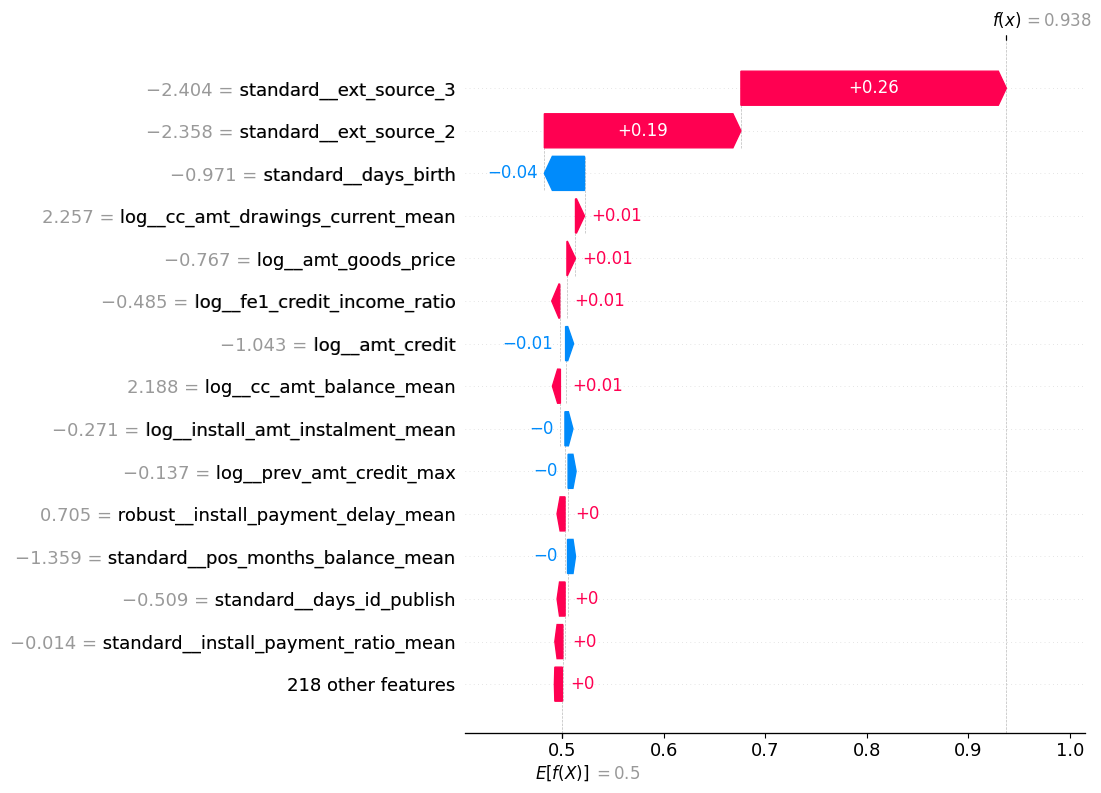


  Rang 5 — Position #27957

  Client position #27957  |  ID=23822
  Probabilité de défaut : 0.9375
  Décision (seuil 0.508) : REFUSÉ ❌
  Réalité               : Défaut (1) ⚠️


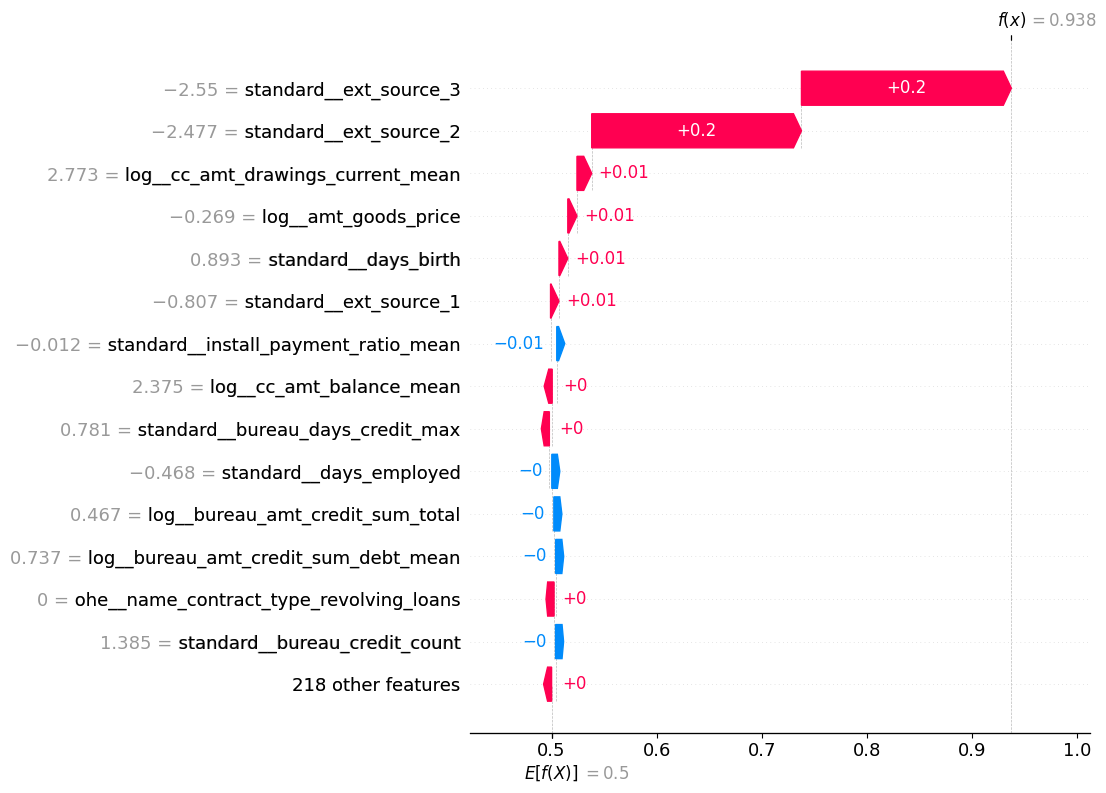

In [26]:
# ── Top 5 clients les plus à risque (selon la probabilité) ────────────────
top5_idx = np.argsort(y_proba)[-5:][::-1]

print("🔍 TOP 5 CLIENTS LES PLUS À RISQUE")
print("=" * 60)
for rank, pos in enumerate(top5_idx, 1):
    print(f"\n  Rang {rank} — Position #{pos}")
    analyser_client(pos, f"top risk #{rank}")


## 📉 11. Dependency Plot — Interaction entre variables

Ce graphique montre comment **l'impact d'une variable** varie selon la valeur d'une autre.
Utile pour détecter des interactions non-linéaires capturées par le modèle.



📊 Impact de 'standard__ext_source_2' (coloré par la variable la plus corrélée)


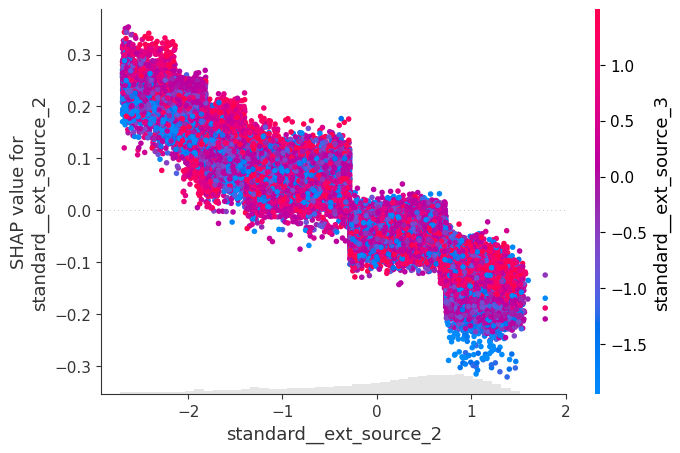


📊 Impact de 'standard__ext_source_3' (coloré par la variable la plus corrélée)


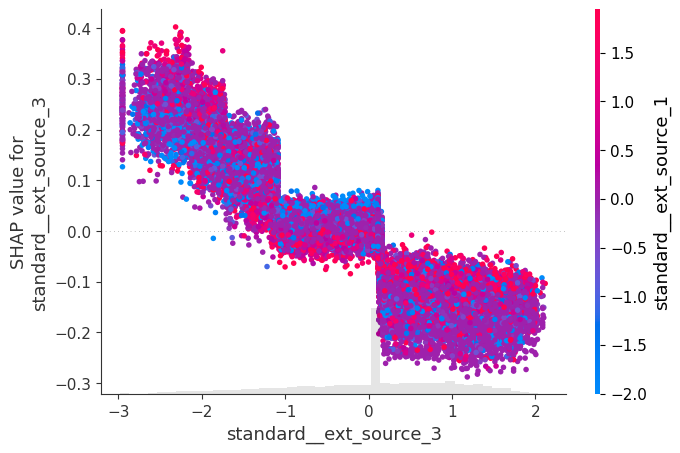

In [28]:
# Top 2 variables SHAP pour les scatter plots

# Obtenemos los nombres de las 2 variables más importantes de tu tabla anterior
top2 = df_shap["Feature"].tolist()[:2]

for feat in top2:
    print(f"\n📊 Impact de '{feat}' (coloré par la variable la plus corrélée)")
    
    # CORRECCIÓN: 
    # 1. Filtramos shap_values para la Clase 1: shap_values[:, :, 1]
    # 2. Seleccionamos la variable específica: [:, feat]
    # 3. Para el color, pasamos todo el objeto de la Clase 1 para que SHAP busque 
    #    automáticamente la interacción más fuerte.
    
    shap_values_clase_1 = shap_values[:, :, 1]
    
    shap.plots.scatter(
        shap_values_clase_1[:, feat], 
        color=shap_values_clase_1
    )


## 📋 12. Rapport Final — Synthèse pour le Chargé d'Études

In [29]:
print("=" * 70)
print("  RAPPORT DE SYNTHÈSE — MODÈLE DE SCORING CRÉDIT")
print("=" * 70)
print(f"  Modèle champion     : {CHAMPION_NAME.upper()}")
print(f"  Run MLflow          : {mlflow_run_id[:8]}...")
print(f"  AUC-ROC (eval)      : {eval_metrics.get('roc_auc', 'N/A')}")
print(f"  F2-Score (eval)     : {eval_metrics.get('f2', 'N/A')}")
print()
print(f"  Seuil optimal       : {seuil_optimal:.3f}  (vs 0.50 par défaut)")
print(f"  Score Métier opt.   : {score_opt}  ({COUT_FN}×{fn_opt} + {COUT_FP}×{fp_opt})")
print()
print("  TOP 5 VARIABLES LES PLUS INFLUENTES (SHAP)")
print("  " + "-" * 50)
for i, row in df_shap.head(5).iterrows():
    print(f"    {i+1}. {row['Feature']:<42} SHAP={row['SHAP_mean_abs']:.4f}")
print()
print("  INTERPRÉTATION MÉTIER")
print("  " + "-" * 50)
print("  • Un score élevé sur EXT_SOURCE_* = client externe bien noté → ↓ risque")
print("  • DAYS_EMPLOYED faible (emploi récent) → ↑ risque de défaut")
print("  • AMT_CREDIT élevé par rapport aux revenus → ↑ risque")
print()
print("  ARTEFACTS PRODUITS")
print("  " + "-" * 50)
for f in REPORTS_DIR.glob("*"):
    print(f"    ✅ {f.name}")
print("=" * 70)


  RAPPORT DE SYNTHÈSE — MODÈLE DE SCORING CRÉDIT
  Modèle champion     : PHASE4_BEST_MODEL
  Run MLflow          : N/A...
  AUC-ROC (eval)      : 0.7116
  F2-Score (eval)     : 0.3854

  Seuil optimal       : 0.508  (vs 0.50 par défaut)
  Score Métier opt.   : 33619  (10×1823 + 1×15389)

  TOP 5 VARIABLES LES PLUS INFLUENTES (SHAP)
  --------------------------------------------------
    1. standard__ext_source_2                     SHAP=0.0949
    2. standard__ext_source_3                     SHAP=0.0883
    3. standard__ext_source_1                     SHAP=0.0350
    4. standard__install_payment_ratio_mean       SHAP=0.0235
    5. standard__days_birth                       SHAP=0.0139

  INTERPRÉTATION MÉTIER
  --------------------------------------------------
  • Un score élevé sur EXT_SOURCE_* = client externe bien noté → ↓ risque
  • DAYS_EMPLOYED faible (emploi récent) → ↑ risque de défaut
  • AMT_CREDIT élevé par rapport aux revenus → ↑ risque

  ARTEFACTS PRODUITS
  ---------